In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi

from splitflow.PlotUtilities import *
from splitflow.FeatureFunctions import *
import matplotlib as mpl

plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

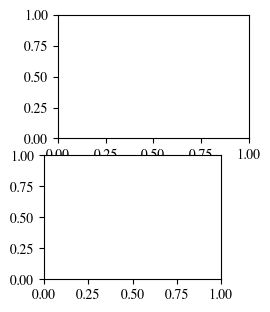

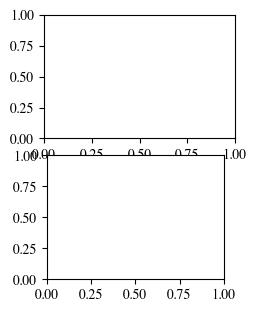

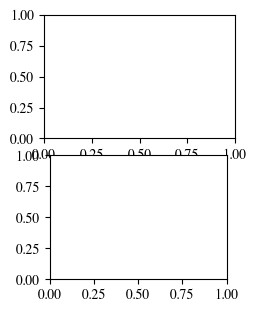

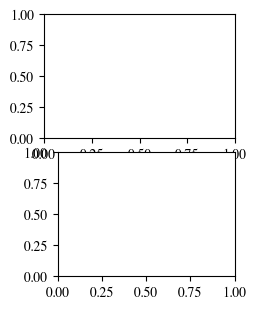

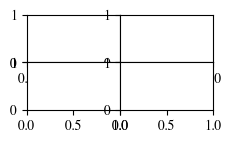

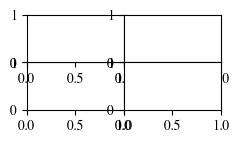

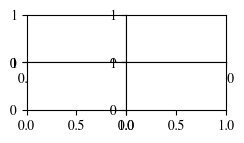

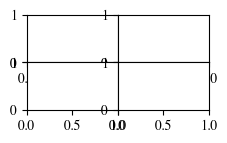

In [2]:
layout = fifi.svg_to_axes.FigureLayout('f3_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])




# Laminar - Control

In [4]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/preprocessed_hdfs/training_laminar_df.hdf')

In [5]:
lam_df = get_normed_positions(lam_df)

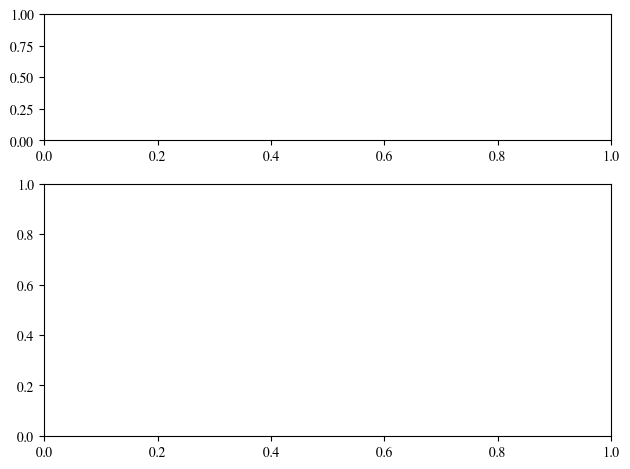

In [6]:
df1_left = lam_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('A1', 'a1')]
ax[1] = layout.axes[('A1', 'a2')]




a = np.linspace(-.5, .5, 300)
b = np.linspace(-.25, .25, 300)
x = np.linspace(-.5, .5, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
#X,Y = np.meshgrid(x,y)
#newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)

ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)



a = np.linspace(-1.25, 1.25, 300)
b = np.linspace(-1.25, 1.25, 300)
x = np.linspace(-1.25, 1.25, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[1].scatter(0,0, color='red', s=5)



fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':5, 'bottom':5},   tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)

ax[0].set_xticklabels(['-0.25','0.0','0.25'])
ax[1].set_yticklabels(['-1','','0','','1'])
ax[1].set_xticklabels(['-1','','0','','1'])
fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].set_xlabel('x position (m)')
ax[0].set_ylabel('y position (m)', labelpad=0)

ax[1].set_xlabel('x velocity (m/s)')
ax[1].set_ylabel('y velocity (m/s)', labelpad=0)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

ax[0].axis('off')
ax[1].axis('off')

layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)

# Bottom Half On

In [8]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/preprocessed_hdfs/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')

In [9]:
bottom_on_df['ground speed'] = np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [10]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [11]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

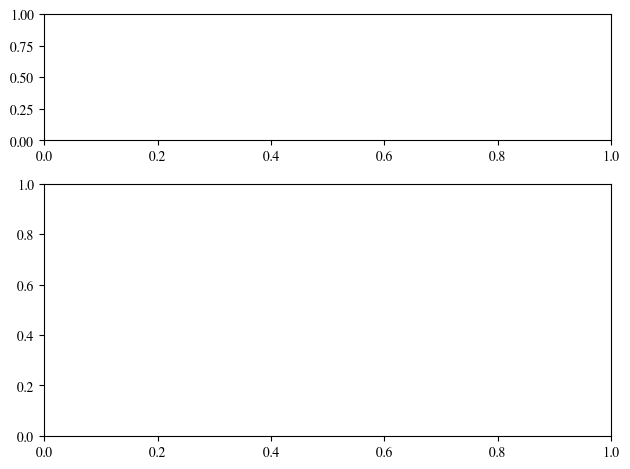

In [12]:
df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('B1', 'b1')]
ax[1] = layout.axes[('B1', 'b2')]




a = np.linspace(-.5, .5, 300)
b = np.linspace(-.25, .25, 300)
x = np.linspace(-.5, .5, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True, zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 300)
b = np.linspace(-1.25, 1.25, 300)
x = np.linspace(-1.25, 1.25, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].axis('off')
ax[1].axis('off')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)

# Top Half On

In [14]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/preprocessed_hdfs/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [15]:
top_on_df['ground speed'] = np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)

In [16]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [17]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

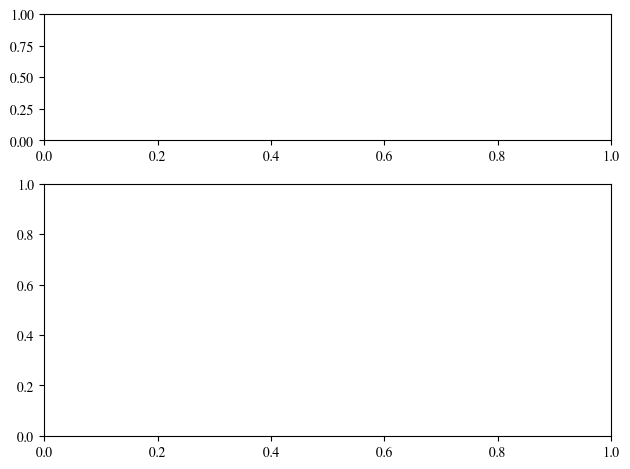

In [18]:
df1_left = flash_low_top_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('C1', 'c1')]
ax[1] = layout.axes[('C1', 'c2')]




a = np.linspace(-.5, .5, 300)
b = np.linspace(-.25, .25, 300)
x = np.linspace(-.5, .5, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 300)
b = np.linspace(-1.25, 1.25, 300)
x = np.linspace(-1.25, 1.25, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


#fifi.mpl_functions.set_fontsize(ax[0], 6)
#fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].axis('off')
ax[1].axis('off')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['C1'], 'C1', cleartarget=True)



# Still air

In [20]:
nw_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/preprocessed_hdfs/training_stillair_df.hdf')

In [21]:
nw_df = get_normed_positions(nw_df)

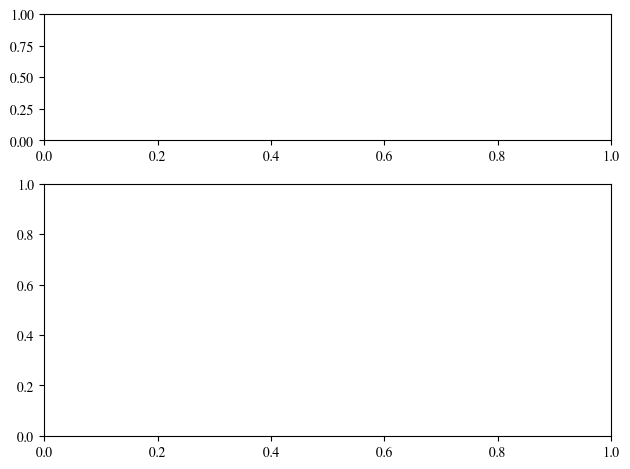

In [22]:
df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('D1', 'd1')]
ax[1] = layout.axes[('D1', 'd2')]




a = np.linspace(-.5, .5, 300)
b = np.linspace(-.25, .25, 300)
x = np.linspace(-.5, .5, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 300)
b = np.linspace(-1.25, 1.25, 300)
x = np.linspace(-1.25, 1.25, 301) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 301)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.00025, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].axis('off')
ax[1].axis('off')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)



# Trajectory Example plots

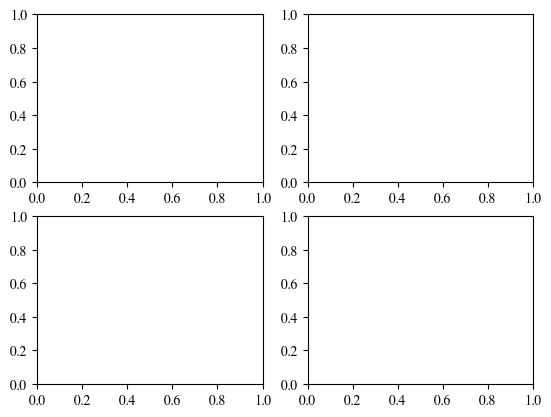

In [32]:
## laminar 

trajs=['318_20220926_173927','687_20220927_170437', '1464_20220926_173927','7178_20220926_173927']

fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('A_t', 't1_a')]
ax[0,1] = layout.axes[('A_t', 't2_a')]
ax[1,0] = layout.axes[('A_t', 't3_a')]
ax[1,1] = layout.axes[('A_t', 't4_a')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    if i==0:
        get_subplot(lam_df, trajs[i], ax=subplot, scale_bar=True)
    else:    
        get_subplot(lam_df, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['A_t'], 'A_t', cleartarget=True)


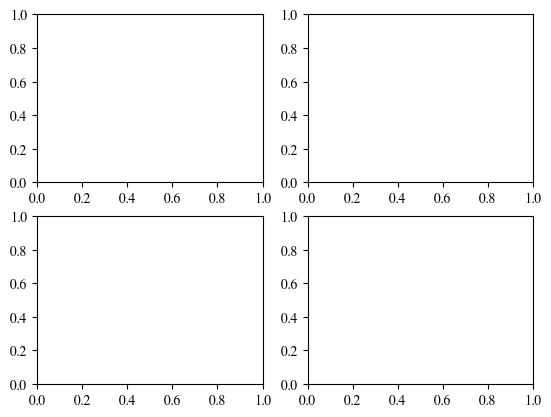

In [34]:
## flash_low_bottom_on: 

trajs=['3661_20240113_171950', '22174_20240113_171950', '8150_20240516_185822', '7224_20240516_185822', '11235_20240516_185822', '11008_2024516_185822']

fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('B_t', 't1_b')]
ax[0,1] = layout.axes[('B_t', 't2_b')]
ax[1,0] = layout.axes[('B_t', 't3_b')]
ax[1,1] = layout.axes[('B_t', 't4_b')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    if i==0:
        get_subplot(flash_low_bottom_on, trajs[i], ax=subplot,scale_bar=True)
    else:    
        get_subplot(flash_low_bottom_on, trajs[i], ax=subplot)

layout.append_figure_to_layer(layout.figures['B_t'], 'B_t', cleartarget=True)


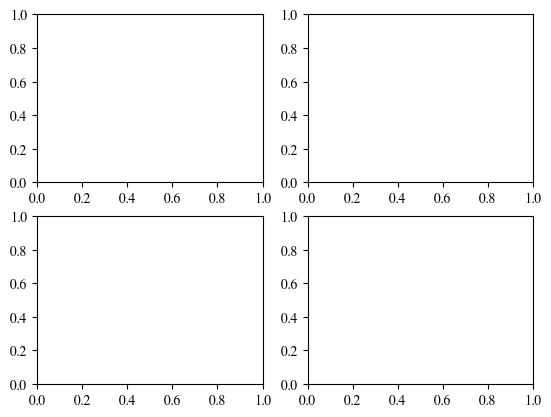

In [36]:
## flash_low_top_on: 

trajs=['10591_20240514_172126', '8827_20240513_181409', '8870_20240513_181409', '8802_20240514_172126', '11411_20240110_164820', '3821_20240515_182700',] 

fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('C_t', 't1_c')]
ax[0,1] = layout.axes[('C_t', 't2_c')]
ax[1,0] = layout.axes[('C_t', 't3_c')]
ax[1,1] = layout.axes[('C_t', 't4_c')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    if i==0:
        get_subplot(flash_low_top_on, trajs[i], ax=subplot,scale_bar=True)
    else:    
        get_subplot(flash_low_top_on, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['C_t'], 'C_t', cleartarget=True)


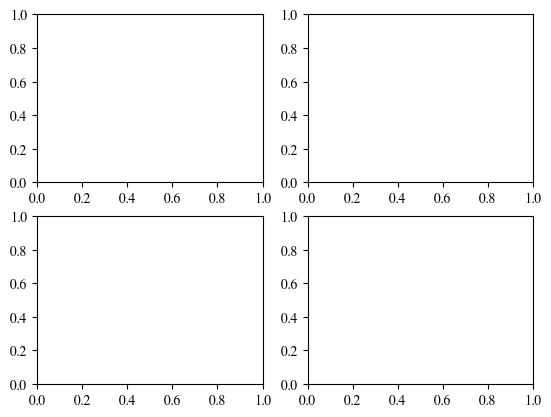

In [38]:
## still air: 

trajs=['3581_20220814_165127','2743_20220813_165621', '2088_20220815_162329', '926_20220814_165127']
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('D_t', 't1_d')]
ax[0,1] = layout.axes[('D_t', 't2_d')]
ax[1,0] = layout.axes[('D_t', 't3_d')]
ax[1,1] = layout.axes[('D_t', 't4_d')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    if i==0:
        get_subplot(nw_df, trajs[i], ax=subplot,scale_bar=True)
    else:    
        get_subplot(nw_df, trajs[i], ax=subplot)

layout.append_figure_to_layer(layout.figures['D_t'], 'D_t', cleartarget=True)


In [40]:
layout.write_svg('f3_raw_data1.svg')